# Figure notebook

Every figure in `figures/` is defined here. To
regenerate them, run the notebook top to bottom and then the Save cell
near the bottom.

Each figure cell builds a `fig` and stashes it in `FIGS` via `keep()`,
which returns nothing on purpose: the inline backend already renders
whatever a cell creates, so returning the figure would draw it twice.
Nothing reaches disk until the Save cell runs.

Re-run the setup cell after editing it, since `keep` is defined
there.


In [33]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from constellaration_uq.data import filter_valid, load_raw
from constellaration_uq.metrics import (
    coverage,
    crps_gaussian,
    deferral_curve,
    distance_bins,
    pit_values,
)
from constellaration_uq.results import REPO_ROOT, load_results
from constellaration_uq.splits import (
    hole_split,
    tail_split,
)

DATA_DIR = REPO_ROOT / 'data_raw' / 'data'
FIGURES_DIR = REPO_ROOT / 'figures'
AXIS = 'metrics.aspect_ratio'
TEST_FRACTION = 0.2

# Percentile 30, so the band runs 20 to 40. Chosen from scripts/hole_placement.py:
# it sits immediately above the tail's percentiles 0 to 20 without overlapping,
# so the hole-versus-edge contrast controls for local sparsity. Defined once here
# because several figures use it and a hardcoded default would drift between them.
HOLE_CENTRE = 0.30

FIGS = {}


def keep(fig, name):
    """Stash a figure for the save cell.

    Deliberately returns nothing. %matplotlib inline already renders every
    figure a cell creates, so returning it would make the cell's output value
    render it a second time and every figure would appear twice.
    """
    FIGS[name] = fig


SEEDS = [0, 1, 2]
COVERAGE_LEVEL = 0.9


def points_for(split, seed):
    """Per-point predictions for one split at one replication seed.

    Seed 0 owns the unsuffixed filename, which is what let replication be
    additive: no script that already read these files had to learn about seeds.
    """
    stem = f'mv_ensemble_{split}' + ('' if seed == 0 else f'_s{seed}')
    return pd.read_csv(REPO_ROOT / 'results' / f'{stem}_points.csv')


def band(ax, x, curves, color, alpha=0.18):
    """Min-max envelope across seeds. Returns the mean for the caller to draw.

    Min-max rather than mean plus or minus one standard deviation. Three seeds
    do not estimate a standard deviation, and a symmetric ribbon would imply a
    precision this does not have.

    What the band means: the hole and tail held-out sets are quantile cutoffs
    with no random component, so they are IDENTICAL across seeds. The spread is
    retraining variability on a fixed test set, not sampling error over shapes.
    """
    stack = np.vstack(curves)
    ax.fill_between(x, stack.min(axis=0), stack.max(axis=0), color=color, alpha=alpha, lw=0)
    return stack.mean(axis=0)


## Style

Edit here rather than per figure. The same colour must mean the same thing
everywhere, which matters more than any individual choice.

In [34]:
# One width for every figure, so the saved PNGs line up when several are shown
# together. Heights still vary with content.
FIG_WIDTH = 7

COLOR_TRAIN =  '#969696' # matches COLOR_NEUTRAL, the in-region color used in cell 37
COLOR_TAIL = '#d94801'
COLOR_HOLE = '#2171b5'
COLOR_NEUTRAL = '#525252'

plt.rcParams.update(
    {
        # Any figure that does not pass figsize explicitly inherits this, so the
        # width belongs here too or that figure alone comes out narrower.
        'figure.figsize': (FIG_WIDTH, 4.5),
        'figure.dpi': 100,
        'savefig.dpi': 100,
        'savefig.bbox': 'tight',
        'axes.grid': True,
        'grid.alpha': 0.25,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 10,
    }
)

## Load the axis

Slow cell, roughly 10 to 20 seconds, almost all of it reading parquet. Only the
aspect ratio column is needed, never the 80-coefficient flatten. Run once.

In [35]:
for _, _df in filter_valid(load_raw(DATA_DIR)):
    pass

axis = _df[AXIS].to_numpy()
print(f'{len(axis):,} rows, aspect ratio {axis.min():.2f} to {axis.max():.2f}')

27,050 rows, aspect ratio 3.92 to 12.11


## Figure 1: where the cuts fall

The explanatory figure. Shows the sampling density, where the tail cut lands,
and how narrow the hole is by comparison.

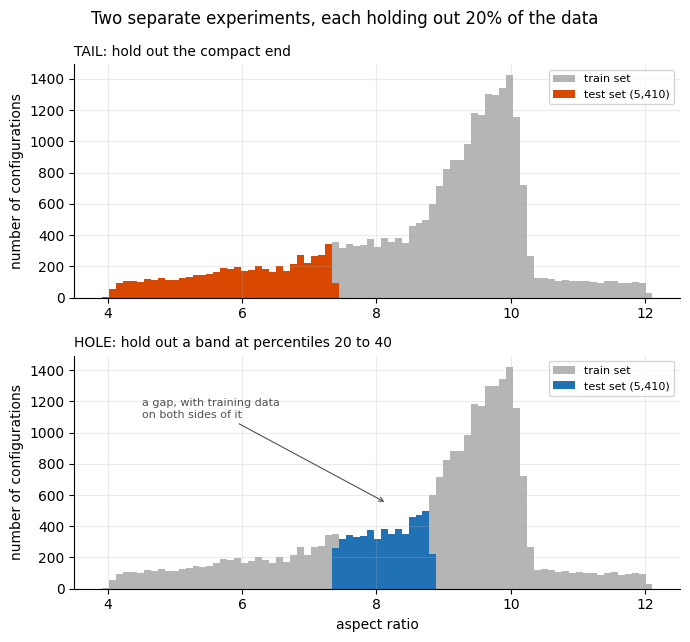

In [36]:
_, tail_test = tail_split(axis, 'low', TEST_FRACTION)
_, hole_test = hole_split(axis, TEST_FRACTION, HOLE_CENTRE)

fig, (ax_tail, ax_hole) = plt.subplots(2, 1, sharex=False, figsize=(FIG_WIDTH, 6.5))
bins = np.linspace(axis.min(), axis.max(), 80)

panels = [
    (ax_tail, tail_test, COLOR_TAIL, 'TAIL: hold out the compact end'),
    (ax_hole, hole_test, COLOR_HOLE, 'HOLE: hold out a band at percentiles 20 to 40'),
]

for ax, test_mask, color, title in panels:
    ax.hist(axis, bins=bins, color=COLOR_TRAIN, label='train set', alpha=0.7)
    ax.hist(axis[test_mask], bins=bins, color=color, label=f'test set ({test_mask.sum():,})')
    ax.set_ylabel('number of configurations')
    ax.set_title(title, fontsize=10, loc='left')
    ax.legend(fontsize=8)

# Tip height derived from the bars so it lands on them rather than above.
hole_counts, _ = np.histogram(axis[hole_test], bins=bins)

ax_hole.annotate(
    'a gap, with training data\non both sides of it',
    xy=(axis[hole_test].mean(), hole_counts.max() * 1.10),
    xytext=(axis.min() + 0.6, hole_counts.max() * 2.2),
    fontsize=8,
    color=COLOR_NEUTRAL,
    arrowprops={'arrowstyle': '->', 'color': COLOR_NEUTRAL, 'lw': 0.8},
)


ax_hole.set_xlabel('aspect ratio')
fig.suptitle('Two separate experiments, each holding out 20% of the data')
fig.tight_layout()

keep(fig, 'split_design')

## Table 1: does the pipeline reproduce Appendix A.4?

Sanity check before any claim of our own: fit the same thing A.4 fit, see if
RMSE lands near Table 7. If it does not, nothing downstream can be trusted.

**Headline row:** our plain-MSE ensemble against theirs, like for like, since
A.4 trained on MSE too. **Other two rows:** single untuned MLPs, 2.4x Table 7
on edge rotational transform and 2.8x on log10 qi. Two unrelated metrics
landing at a similar multiple is evidence the plumbing is right, not just luck
on one metric.

**RMSE only, never R².** R² depends on the test set's own spread, which
differs from theirs, so it reads far worse than the RMSE ratio implies.

No log10 qi ensemble exists, that row is a single untuned MLP from an earlier
scan over candidate targets and split axes. Our pool is 27,050 against A.4's
stated ~23k; the filter chain matches their published loader exactly, so the
gap is in their appendix, not ours.


In [37]:
mse = load_results('mse_ensemble')['results']
grid_rows = load_results('day_1_2_grid')['results']['rows']


def grid_in_region(target):
    """In-region RMSE for one target from the day 1-2 grid.

    Averaged over the three cuts of the winning axis. Each is a separate fit of
    the same untuned single MLP, and they differ only in which rows were held
    out, so their in-region numbers are three samples of one quantity.
    """
    matching = [
        r['rmse_in'] for r in grid_rows if r['target'] == target and r['axis'] == 'aspect_ratio'
    ]
    return float(np.mean(matching))


# Table 7 values, transcribed from the paper. Stored in the results file for the
# primary target; the qi figure has no run of ours to sit beside it.
TABLE_7 = {
    'edge_rotational_transform_over_n_field_periods': mse['table_7_rmse'],
    'log_10_qi': 0.051,
}

comparison = pd.DataFrame(
    [
        {
            'metric': 'edge rotational transform',
            'model': 'ours: 10-member MSE ensemble',
            'table_7_rmse': TABLE_7['edge_rotational_transform_over_n_field_periods'],
            'our_rmse': mse['ensemble_rmse'],
        },
        {
            'metric': 'edge rotational transform',
            'model': 'ours: one untuned MLP',
            'table_7_rmse': TABLE_7['edge_rotational_transform_over_n_field_periods'],
            'our_rmse': grid_in_region('edge_rot_transform'),
        },
        {
            'metric': 'log10 qi',
            'model': 'ours: one untuned MLP (no ensemble run)',
            'table_7_rmse': TABLE_7['log_10_qi'],
            'our_rmse': grid_in_region('log10_qi'),
        },
    ]
)
comparison['ratio'] = comparison['our_rmse'] / comparison['table_7_rmse']
comparison.round({'table_7_rmse': 4, 'our_rmse': 5, 'ratio': 2})

,metric,model,table_7_rmse,our_rmse,ratio
0,edge rotational transform,ours: 10-member MSE ensemble,0.006,0.01052,1.75
1,edge rotational transform,ours: one untuned MLP,0.006,0.01458,2.43
2,log10 qi,ours: one untuned MLP (no ensemble run),0.051,0.14489,2.84


## Table 2: the decomposition, and where calibration breaks

The project's headline result. Three splits, each with its own ten-network
ensemble, tested on two groups: familiar shapes and held-out shapes.

**The `ratio` column matters most.** Predicted uncertainty divided by actual
error. 1.0 is honest, above is cautious, below is overconfident.

On familiar shapes, ratio is 1.04 to 1.18: slightly cautious, the safe
direction. On held-out shapes it drops to 0.69 (hole) and 0.66 (tail): the
model is overconfident there. The random split barely moves between the two,
which confirms this drop is real, not a measurement artifact.

`cov@0.9`: what fraction of true values fall inside the model's own 90%
interval. In region, 95 to 97%. At the tail, 78%. `pit_mean` catches what
coverage cannot: a value below 0.5 means predictions are biased in one
direction, not just too narrow an interval.

**All numbers here are from one training run.** Table 3 repeats these on two
more runs to confirm they hold up.

In [38]:
calibration = load_results('calibration')['results']

LABELS = {'random': 'random', 'hole': 'hole p30', 'tail': 'tail-low'}

decomposition = pd.DataFrame(
    [
        {
            'split': LABELS[name],
            'region': region.replace('-region', '').replace('-of', ''),
            'n': sets[region]['n'],
            'rmse': sets[region]['rmse'],
            'epistemic': sets[region]['epistemic'],
            'aleatoric': sets[region]['aleatoric'],
            'total': sets[region]['total'],
            'ratio': sets[region]['total_over_rmse'],
            'cov@0.9': sets[region]['coverage_0.9'],
            'pit_mean': sets[region]['pit_mean'],
        }
        for name in ('random', 'hole', 'tail')
        for sets in [calibration[name]['sets']]
        for region in ('in-region', 'out-of-region')
    ]
)
decomposition.round(
    {'rmse': 5, 'epistemic': 5, 'aleatoric': 5, 'total': 5, 'ratio': 2, 'cov@0.9': 3, 'pit_mean': 3}
)

,split,region,n,rmse,epistemic,aleatoric,total,ratio,cov@0.9,pit_mean
0,random,in,4324,0.01256,0.00887,0.01194,0.01487,1.18,0.966,0.518
1,random,out,5404,0.01280,0.00895,0.01161,0.01466,1.15,0.962,0.514
2,hole p30,in,4324,0.01252,0.00813,0.01010,0.01297,1.04,0.950,0.506
3,hole p30,out,5404,0.02484,0.01197,0.01209,0.01702,0.69,0.871,0.531
4,tail-low,in,4324,0.01223,0.00834,0.01032,0.01327,1.09,0.956,0.507
5,tail-low,out,5405,0.03962,0.01457,0.02189,0.02630,0.66,0.779,0.348


## Table 3: does it survive a different seed?

Table 2 came from one training run. A different random seed changes network
initialization and shuffling, so this repeats every measurement on seeds 0, 1
and 2 to check the findings are not a fluke of that one run.

**What moves with the seed, and what doesn't.** Initialization, shuffling, and
the training/validation split all vary. The hole and tail held-out test sets
do not, since they're a fixed cutoff on the data, not a random draw. So only
the random split's test set changes across seeds.

**The finding.** Seed-to-seed noise is 0.2% to 6.7%. Every gap reported in
Table 2 is roughly ten times larger than that, so none of it is an accident of
which seed got used. The random split (the control) stays flat at 1.03 ± 0.01
across seeds, confirming it isn't manufacturing a gap where there isn't one.


In [39]:
seed_spread = load_results('seed_spread')['results']


def pm(stat, places):
    """Format a mean and its spread into one cell.

    Strings rather than floats on purpose: a float column would render the mean
    and silently drop the spread, which is the half that makes the row a claim
    rather than a number.
    """
    return f'{stat["mean"]:.{places}f} ± {stat["std"]:.{places}f}'


replication = pd.DataFrame(
    [
        {
            'split': LABELS[name],
            'seeds': len(split['seeds']),
            'out/in rmse': pm(summary['gap'], 2),
            'in ratio': pm(summary['in_ratio'], 3),
            'out ratio': pm(summary['out_ratio'], 3),
            'out cov@0.9': pm(summary['out_coverage'], 3),
            'out pit_mean': pm(summary['out_pit_mean'], 3),
        }
        for name in ('random', 'hole', 'tail')
        for split in [seed_spread['splits'][name]]
        for summary in [split['summary']]
    ]
)
replication

,split,seeds,out/in rmse,in ratio,out ratio,out cov@0.9,out pit_mean
0,random,3,1.03 ± 0.01,1.140 ± 0.039,1.105 ± 0.047,0.959 ± 0.003,0.509 ± 0.008
1,hole p30,3,1.90 ± 0.12,1.075 ± 0.072,0.725 ± 0.028,0.878 ± 0.005,0.534 ± 0.002
2,tail-low,3,3.32 ± 0.10,1.132 ± 0.034,0.677 ± 0.021,0.788 ± 0.017,0.353 ± 0.012


## Hole placement: a decision, not a figure

Before running the headline experiment, this settles where the "gap" region
(one of three held-out test regions) should sit. It ended up spanning
percentiles 20 to 40, directly against the "cut off the end" region's 0 to 20,
with no gap and no overlap between them. That keeps the two experiments
comparable later on, so it's recorded here as a table rather than folded
silently into the setup.

The table below tries different positions for a 20-point-wide window, sliding
it along the data in steps of 10, and measures how much worse the model does
inside each one. `results/hole_placement.json` holds that sweep.
`results/hole_placement_narrow.json` repeats it with a narrower, 10-point
window, which reaches further toward the sparse end of the data. That
narrower sweep shows the penalty is worst at both edges and lowest in the
middle, meaning the width of the gap matters more than which end it's near.
Treat that as suggestive rather than solid: the two rows driving it rest on
noticeably fewer points than the rest of the table.


In [40]:
placement = load_results('hole_placement')['results']['rows']

pd.DataFrame(placement)[
    [
        'split',
        'percentiles',
        'n_held_out',
        'rmse_in',
        'rmse_out',
        'ratio',
        'reach',
        'min_bin',
        'delta',
    ]
].round({'rmse_in': 5, 'rmse_out': 5, 'ratio': 2, 'reach': 2, 'delta': 3})

,split,percentiles,n_held_out,rmse_in,rmse_out,ratio,reach,min_bin,delta
0,tail-low,0 to 20,5405,0.01379,0.04157,3.02,2.13,276,0.059
1,hole,10 to 30,5404,0.01417,0.02777,1.96,0.63,602,0.040
2,hole,20 to 40,5404,0.01452,0.02615,1.80,0.45,583,0.041
3,hole,30 to 50,5404,0.01479,0.01658,1.12,0.31,586,0.040
4,hole,40 to 60,5404,0.01476,0.01406,0.95,0.20,641,0.039
5,hole,50 to 70,5404,0.01526,0.01377,0.90,0.16,616,0.039
6,hole,60 to 80,5404,0.01552,0.01240,0.80,0.14,645,0.039
7,hole,70 to 90,5404,0.01567,0.01283,0.82,0.13,602,0.040


## Figure 2: error against distance from the training data

Every point on these curves is a bin of roughly 675 held-out configurations,
not a whole separate experiment, which is what makes this readable in a way
the placement sweep isn't.

Three splits, one model each, same recipe throughout. Each curve starts at
that split's own in-region error, then follows the binned error outward as
distance from the training data increases.

**The finding.** At matched distance, the tail sits above the hole by about
12% over the range where both have data (0.02929 vs 0.02615). Most of the
larger headline gap (3.02 vs 1.80) is simply distance: the tail split asks
about configurations that are much further from the data. What's left after
controlling for distance is the real cost of leaving the training region
entirely, and it's real but modest.

**This is the weakest claim in the project**, and the only one close to seed
noise. Across three seeds the premium is 1.156 ± 0.052, roughly three
standard deviations from no effect, where every other finding clears its
seed noise by an order of magnitude.

The shaded band marks the only range where both splits have data, so it's
the only range where this comparison is possible at all. Past that point the
tail continues alone.


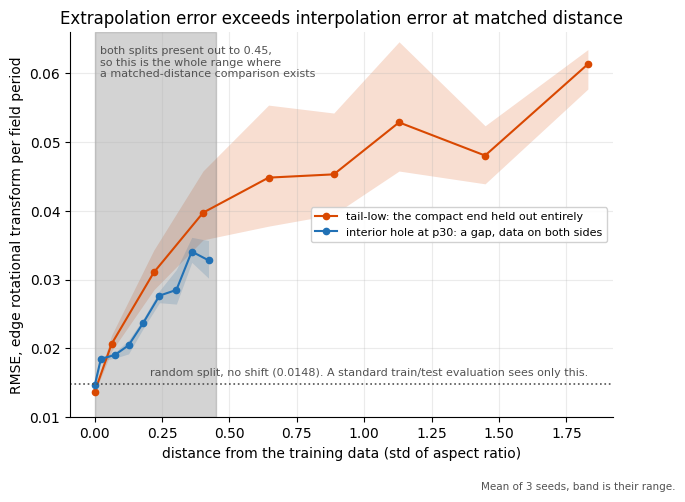

In [41]:
# Three independent fits per split. The bins are identical across seeds, since
# distance depends only on the axis and the training mask and both splits use
# fixed quantile cutoffs, so the curves can be averaged pointwise.
by_seed = [
    load_results('distance_error' + ('' if s == 0 else f'_s{s}'))['results']['splits']
    for s in SEEDS
]
splits = by_seed[0]

SERIES_DISTANCE_ERROR = {
    'tail_low': ('tail-low: the compact end held out entirely', COLOR_TAIL),
    'hole_p30': ('interior hole at p30: a gap, data on both sides', COLOR_HOLE),
}

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 5))

# Pinned so the other annotations below have somewhere reliable to sit.
ax.set_ylim(0.010, 0.066)

for name, (label, color) in SERIES_DISTANCE_ERROR.items():
    # Each curve starts from its own in-region error at distance zero rather
    # than from a shared baseline. The two differ by about 5%, and drawing one
    # line for both would hide that.
    d = [0.0, *[b['d_median'] for b in splits[name]['bins']]]
    curves = [
        [seed[name]['in_region']['rmse'], *[b['rmse'] for b in seed[name]['bins']]]
        for seed in by_seed
    ]
    err = band(ax, d, curves, color)
    ax.plot(d, err, 'o-', color=color, markersize=4.5, label=label)

# The random split is a reference level, not a series. Its held-out points never
# get more than 0.01 from training data, so drawn as a curve it is eight dots on
# the y axis that read as noise on the other two. As a line it does the job it is
# actually for: making the vertical gap to the no-shift baseline readable at
# every distance.
random = splits['random']
far = splits['tail_low']['bins'][-1]['d_median']
ax.axhline(random['rmse_out'], color=COLOR_NEUTRAL, linestyle=':', linewidth=1.2)
ax.annotate(
    f'random split, no shift ({random["rmse_out"]:.4f}). '
    'A standard train/test evaluation sees only this.',
    (far, random['rmse_out']),
    textcoords='offset points',
    xytext=(0, 6),
    ha='right',
    fontsize=8,
    color=COLOR_NEUTRAL,
)

# The hole cannot reach past here, so neither can the comparison. Sits inside
# the band, top left, where both curves are still low.
overlap = splits['hole_p30']['reach']
ax.axvspan(0, overlap, color=COLOR_NEUTRAL, alpha=0.25)
ax.annotate(
    f'both splits present out to {overlap:.2f},\nso this is the whole range where\n'
    'a matched-distance comparison exists',
    (0.02, 0.064),
    va='top',
    ha='left',
    fontsize=8,
    color=COLOR_NEUTRAL,
)

ax.set_xlabel('distance from the training data (std of aspect ratio)')
ax.set_ylabel('RMSE, edge rotational transform per field period')
ax.set_title('Extrapolation error exceeds interpolation error at matched distance')
ax.legend(fontsize=8, loc='center right', framealpha=0.9)

# Below the axes, not inside them. Every free corner of this panel is one a
# curve reaches at some seed, and a caption that collides with data is worse
# than no caption.
fig.text(
    0.99,
    -0.02,
    f'Mean of {len(SEEDS)} seeds, band is their range.',
    ha='right',
    va='top',
    fontsize=7.5,
    color=COLOR_NEUTRAL,
)

keep(fig, 'distance_error')

## Load the uncertainty results

Everything below reads `results/*.json` and `results/*.csv` written by
`scripts/calibration.py`, `scripts/deferral.py` and `scripts/n_sweep.py`. No
training, no parquet, under a second.


In [42]:
cal = load_results('calibration')
calibration = cal['results']
LEVELS = cal['constants']['LEVELS']

sweep = load_results('n_sweep')
sweep_cells = sweep['results']['cells']

# pts.split would call DataFrame.split, not the column. Always bracket it.
pit_points = pd.read_csv(REPO_ROOT / 'results' / 'calibration_points.csv')

print('splits:', list(calibration))
print('nominal levels:', LEVELS)
print('sweep cells:', len(sweep_cells), 'complete:', sweep['results']['complete'])


splits: ['random', 'hole', 'tail']
nominal levels: [0.5, 0.68, 0.8, 0.9, 0.95, 0.99]
sweep cells: 30 complete: True


## Figure 3: does the model know when it's wrong?

Same x axis as Figure 2, so the two can be read side by side. Figure 2 shows
error growing with distance from the training data. On its own, that's not a
problem, since a model that widens its error bars as it gets worse is doing
the right thing. This figure checks whether it actually does that.

The y axis is the fraction of true values that landed inside the model's own
stated 90% interval. If the model is honest, that fraction should stay near
90% at every distance, the dotted line.

**The finding.** It doesn't. In region, the interval holds 95 to 97% of true
values, slightly better than promised. Past the compact edge, that falls to
59%, so a "90% interval" is really closer to a 60% interval out there. The
hole degrades too, but less sharply, and it levels off instead of continuing
to fall.


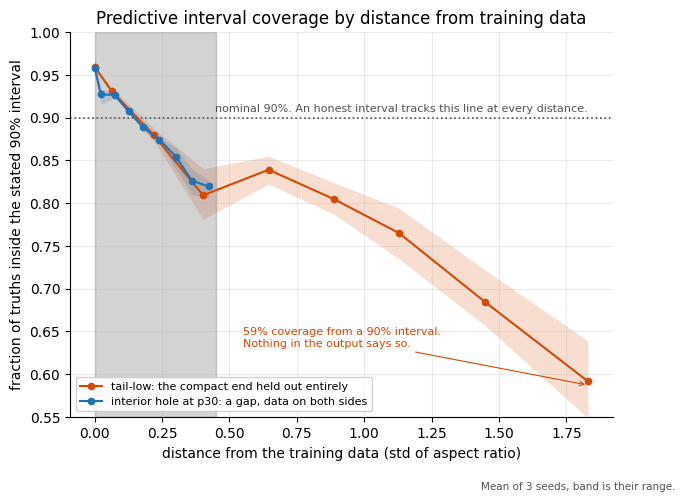

In [43]:
def coverage_by_distance(split, seed):
    """Coverage at nominal 90% per distance bin, for one seed.

    Recomputed here rather than read from calibration.json, which only covers
    seed 0. Uses the same metrics.distance_bins and metrics.coverage the script
    uses, so the seed 0 curve reproduces calibration_bins.csv exactly.
    """
    df = points_for(split, seed)
    out = df[df['region'] == 'out']
    rows, masks = distance_bins(out['distance'].to_numpy(), N_DISTANCE_BINS)
    per_bin = [
        coverage(
            out['y_true'].to_numpy()[m],
            out['mean'].to_numpy()[m],
            out['total_variance'].to_numpy()[m],
            COVERAGE_LEVEL,
        )
        for m in masks
    ]
    anchor = df[df['region'] == 'in']
    in_region = coverage(
        anchor['y_true'], anchor['mean'], anchor['total_variance'], COVERAGE_LEVEL
    )
    return [0.0, *[r['d_median'] for r in rows]], [in_region, *per_bin]


N_DISTANCE_BINS = cal['constants']['N_BINS']

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 5))

SERIES_POINTS = {
    'tail': ('tail-low: the compact end held out entirely', COLOR_TAIL),
    'hole': ('interior hole at p30: a gap, data on both sides', COLOR_HOLE),
}

curves = {}

for name, (label, color) in SERIES_POINTS.items():
    # In-region is one anchor at distance zero, not the first bin, matching the
    # convention in Figure 2 and in scripts/calibration.py.
    per_seed = [coverage_by_distance(name, s) for s in SEEDS]
    d = per_seed[0][0]
    cov = band(ax, d, [c for _, c in per_seed], color)
    ax.plot(d, cov, 'o-', color=color, markersize=4.5, label=label)
    curves[name] = (d, cov)

ax.axhline(0.9, color=COLOR_NEUTRAL, linestyle=':', linewidth=1.2)
# Right-aligned at the far edge. On the left it sat inside the shaded band, on
# top of both curves where they are still near 0.9.
ax.annotate(
    'nominal 90%. An honest interval tracks this line at every distance.',
    (max(curves['tail'][0]), 0.905),
    fontsize=8,
    color=COLOR_NEUTRAL,
    ha='right',
    va='bottom',
)

overlap = max(b['d_hi'] for b in calibration['hole']['bins'])
ax.axvspan(0, overlap, color=COLOR_NEUTRAL, alpha=0.25)

# Seed 0, matching the number quoted in the text and in calibration.json.
worst = calibration['tail']['bins'][-1]
ax.annotate(
    f'{worst["coverage_0.9"]:.0%} coverage from a 90% interval.\nNothing in the output says so.',
    xy=(worst['d_median'], worst['coverage_0.9']),
    xytext=(0.55, 0.655),
    fontsize=8,
    color=COLOR_TAIL,
    ha='left',
    va='top',
    arrowprops={'arrowstyle': '->', 'color': COLOR_TAIL, 'lw': 0.8},
)

ax.set_ylim(0.55, 1.0)
ax.set_xlabel('distance from the training data (std of aspect ratio)')
ax.set_ylabel('fraction of truths inside the stated 90% interval')
ax.set_title('Predictive interval coverage by distance from training data')
ax.legend(fontsize=8, loc='lower left', framealpha=0.9)

fig.text(
    0.99,
    -0.02,
    f'Mean of {len(SEEDS)} seeds, band is their range.',
    ha='right',
    va='top',
    fontsize=7.5,
    color=COLOR_NEUTRAL,
)

keep(fig, 'coverage_distance')

## Figure 3b: is the tail biased, or just imprecise?

Coverage can't tell you which: an interval can miss because it's too narrow,
or because it's centered on the wrong value. PIT can: it's where each true
value lands inside its predicted range, 0 to 1. Averaged over many points, an
unbiased model sits at 0.5. Below that means predictions are consistently too
high.

**The finding.** The hole stays flat around 0.52 to 0.55, no trend. The tail
starts at 0.43 nearby and drops to 0.15 far out, it's genuinely biased, not
just imprecise.

This is also why Figure 6's fix backfires off-distribution: it only widens or
narrows the interval, so it can't fix a problem that's in the center.


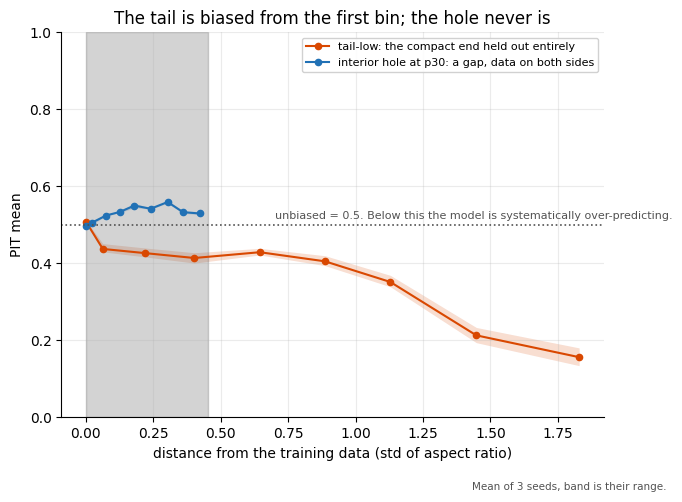

In [44]:
def pit_by_distance(split, seed):
    """PIT mean per distance bin, for one seed.

    Same shape as coverage_by_distance in the previous cell: same
    distance_bins call, same in-region anchor at distance 0, so the two
    figures share bins and can be read side by side. Recomputed here rather
    than read from calibration_bins.csv, which only covers seed 0.
    """
    df = points_for(split, seed)
    out = df[df['region'] == 'out']
    rows, masks = distance_bins(out['distance'].to_numpy(), N_DISTANCE_BINS)
    per_bin = [
        float(pit_values(
            out['y_true'].to_numpy()[m],
            out['mean'].to_numpy()[m],
            out['total_variance'].to_numpy()[m],
        ).mean())
        for m in masks
    ]
    anchor = df[df['region'] == 'in']
    in_region = float(
        pit_values(anchor['y_true'], anchor['mean'], anchor['total_variance']).mean()
    )
    return [0.0, *[r['d_median'] for r in rows]], [in_region, *per_bin]


fig, ax = plt.subplots(figsize=(FIG_WIDTH, 5))

SERIES_POINTS = {
    'tail': ('tail-low: the compact end held out entirely', COLOR_TAIL),
    'hole': ('interior hole at p30: a gap, data on both sides', COLOR_HOLE),
}

for name, (label, color) in SERIES_POINTS.items():
    per_seed = [pit_by_distance(name, s) for s in SEEDS]
    d = per_seed[0][0]
    pit = band(ax, d, [c for _, c in per_seed], color)
    ax.plot(d, pit, 'o-', color=color, markersize=4.5, label=label)

ax.axhline(0.5, color=COLOR_NEUTRAL, linestyle=':', linewidth=1.2)
ax.annotate(
    'unbiased = 0.5. Below this the model is systematically over-predicting.',
    (0.7, 0.51),
    fontsize=8,
    color=COLOR_NEUTRAL,
    ha='left',
    va='bottom',
)

overlap = max(b['d_hi'] for b in calibration['hole']['bins'])
ax.axvspan(0, overlap, color=COLOR_NEUTRAL, alpha=0.25)

ax.set_ylim(0, 1)
ax.set_xlabel('distance from the training data (std of aspect ratio)')
ax.set_ylabel('PIT mean')
ax.set_title('The tail is biased from the first bin; the hole never is')
ax.legend(fontsize=8, loc='upper right', framealpha=0.9)

fig.text(
    0.99,
    -0.02,
    f'Mean of {len(SEEDS)} seeds, band is their range.',
    ha='right',
    va='top',
    fontsize=7.5,
    color=COLOR_NEUTRAL,
)

keep(fig, 'pit_distance')

## Figure 4: calibration at every confidence level

Figure 3 fixes the confidence level at 90% and varies distance. This does the
opposite: it sweeps the level and separates in-region from out-of-region, so a
reader can check the failure is not an artifact of one arbitrary choice.

The diagonal is perfect calibration. Above it the model is conservative, below
it overconfident. Random is the control and should sit on the diagonal in both
regions, which is what makes the other two panels readable as shift rather than
as a quirk of the diagnostic.


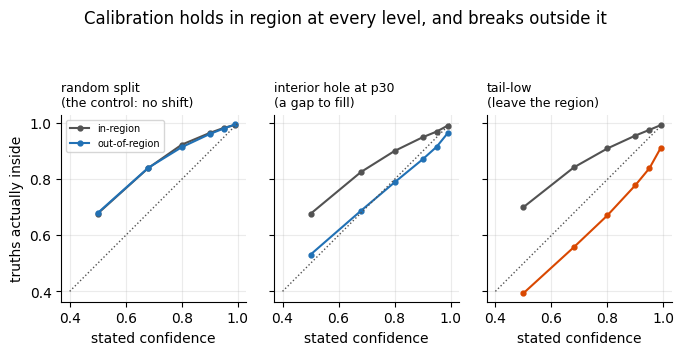

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, 3.8), sharex=True, sharey=True)

TITLES = {
    'random': 'random split\n(the control: no shift)',
    'hole': 'interior hole at p30\n(a gap to fill)',
    'tail': 'tail-low\n(leave the region)',
}

for ax, (name, title) in zip(axes, TITLES.items(), strict=True):
    for region, color, style in (
        ('in-region', COLOR_NEUTRAL, '-'),
        ('out-of-region', COLOR_TAIL if name == 'tail' else COLOR_HOLE, '-'),
    ):
        measured = [calibration[name]['sets'][region]['coverage'][f'{lv:g}'] for lv in LEVELS]
        ax.plot(LEVELS, measured, style, marker='o', markersize=3.5, color=color, label=region)

    ax.plot([0.4, 1.0], [0.4, 1.0], ':', color=COLOR_NEUTRAL, linewidth=1)
    ax.set_title(title, fontsize=9, loc='left')
    ax.set_xlabel('stated confidence')
    ax.set_aspect('equal')

axes[0].set_ylabel('truths actually inside')
axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle('Calibration holds in region at every level, and breaks outside it')
fig.tight_layout()

keep(fig, 'coverage_nominal')

## Figure 5: what kind of wrong

Figure 3b showed the average PIT value. This shows the full spread, which
reveals the **shape** a mean can't: piled up at both ends means intervals too
narrow but centered right; leaning to one side means the center itself is
biased.

**The finding.** The tail's out-of-region panel leans hard left, mean 0.348
against 0.51 elsewhere. The truth keeps landing below the prediction, the
model is confidently wrong in one direction. The hole shows none of this.

Shown in aggregate, not split by distance, since each distance bin would only
have about 60 points, too few to trust the shape.


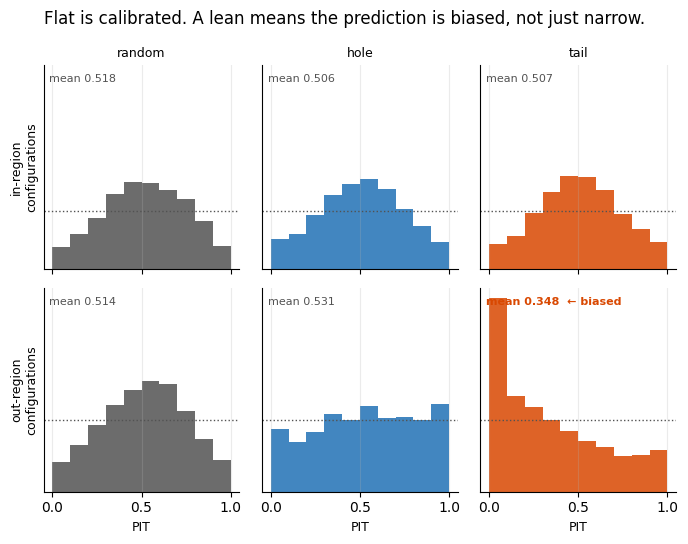

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(FIG_WIDTH, 5.5), sharex=True, sharey=True)

COLUMNS = ['random', 'hole', 'tail']
bins = np.linspace(0, 1, 11)

for col, name in enumerate(COLUMNS):
    for row, region in enumerate(['in', 'out']):
        ax = axes[row, col]
        sel = pit_points[(pit_points['split'] == name) & (pit_points['region'] == region)]
        color = COLOR_TAIL if name == 'tail' else COLOR_HOLE
        if name == 'random':
            color = COLOR_NEUTRAL

        ax.hist(sel['pit'], bins=bins, color=color, alpha=0.85)
        ax.axhline(len(sel) / 10, color=COLOR_NEUTRAL, linestyle=':', linewidth=1)

        mean_pit = sel['pit'].mean()
        biased = abs(mean_pit - 0.5) > 0.05
        ax.annotate(
            f'mean {mean_pit:.3f}' + ('  ← biased' if biased else ''),
            (0.03, 0.92),
            xycoords='axes fraction',
            fontsize=8,
            color=COLOR_TAIL if biased else COLOR_NEUTRAL,
            fontweight='bold' if biased else 'normal',
        )
        if row == 0:
            ax.set_title(name, fontsize=9)
        if col == 0:
            ax.set_ylabel(f'{region}-region\nconfigurations', fontsize=9)
        ax.set_yticks([])

for ax in axes[1]:
    ax.set_xlabel('PIT', fontsize=9)

fig.suptitle('Flat is calibrated. A lean means the prediction is biased, not just narrow.')
fig.tight_layout()

keep(fig, 'pit_histograms')


## Figure 6: the standard fix makes it worse

The obvious objection to Figures 3 to 5: "the model is overconfident at the
compact edge, so just recalibrate it." This measures what actually happens if
you do.

**The method:** scale every predicted uncertainty by one number per split,
fitted on held-out in-region data only, since using out-of-region data would
assume access to the exact labels the whole problem says are unavailable.

**The result, in three parts:**

1. **It works where it's fitted.** In region, every arrow moves toward the
   target. The method isn't broken.
2. **It transfers fine when there's no shift.** The random split's
   out-of-region arrow also improves. This is the control: if the fix broke
   everything indiscriminately, it would prove nothing.
3. **It makes things worse under real shift.** The hole and tail
   out-of-region arrows move the wrong way. At the compact edge, a stated 90%
   interval held 78% of true values before, and **67%** after.

Two more signs point the same way: CRPS gets worse out of region on both
shifted splits, and PIT barely moves at the tail (0.348 to 0.333), confirming
this is a centering problem a width fix can't touch.

**This is reporting only.** It doesn't feed into the deferral ranking, and it
can't: a single positive scaling factor can't reorder points, so the ranking
is untouched no matter what.


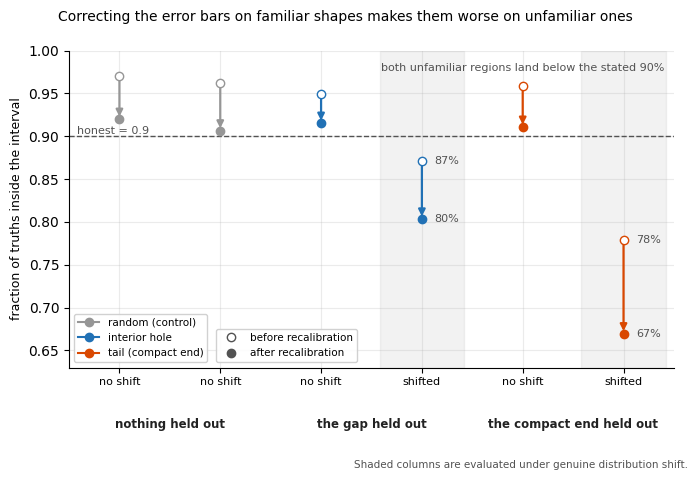

In [47]:
from matplotlib.lines import Line2D

recal = load_results('recalibration')['results']

COLOR_BY_SPLIT = {'random': COLOR_TRAIN, 'hole': COLOR_HOLE, 'tail': COLOR_TAIL}
COMBOS = [(s, r) for s in ('random', 'hole', 'tail') for r in ('in', 'out')]
# The two columns where the evaluation set is genuinely shifted. Shaded so the
# eye finds them without having to compare six pairs of arrow lengths.
SHIFTED = [i for i, (s, r) in enumerate(COMBOS) if r == 'out' and s != 'random']

TARGET, YLABEL = 0.9, 'fraction of truths inside the interval'

# The README reaches this figure before it has introduced "hole", "tail" or
# "in/out of region", so the labels need no prior vocabulary.
PLAIN_COLUMNS = ['no shift', 'no shift', 'no shift', 'shifted', 'no shift', 'shifted']
PLAIN_GROUPS = ['nothing held out', 'the gap held out', 'the compact end held out']

# Two legends, not one merged list: colour answers "which split" and marker
# shape answers "before or after", and those are independent questions.
SPLIT_LEGEND_LABELS = {
    'random': 'random (control)',
    'hole': 'interior hole',
    'tail': 'tail (compact end)',
}
SPLIT_HANDLES = [
    Line2D(
        [0], [0], color=COLOR_BY_SPLIT[s], marker='o', markersize=6, linestyle='-',
        label=SPLIT_LEGEND_LABELS[s],
    )
    for s in ('random', 'hole', 'tail')
]
MARKER_HANDLES = [
    Line2D(
        [0], [0], marker='o', color=COLOR_NEUTRAL, markerfacecolor='white',
        markersize=6, linestyle='none', label='before recalibration',
    ),
    Line2D(
        [0], [0], marker='o', color=COLOR_NEUTRAL, markerfacecolor=COLOR_NEUTRAL,
        markersize=6, linestyle='none', label='after recalibration',
    ),
]

# What the shading means doesn't fit either legend, colour and marker shape are
# both already spoken for, so it stays a short caption instead of a third
# legend entry.
SHIFT_CAPTION = 'Shaded columns are evaluated under genuine distribution shift.'


def draw_panel(ax):
    """Before/after coverage at nominal 90%, one arrow per split/region combo."""
    for x in SHIFTED:
        ax.axvspan(x - 0.42, x + 0.42, color=COLOR_NEUTRAL, alpha=0.07, zorder=0)

    for x, (split, region) in enumerate(COMBOS):
        before = recal[split][region]['before']['coverage']
        after = recal[split][region]['after']['coverage']
        color = COLOR_BY_SPLIT[split]

        # The arrow carries the direction; open marker is before, filled is after.
        ax.annotate(
            '',
            xy=(x, after),
            xytext=(x, before),
            arrowprops={'arrowstyle': '-|>', 'color': color, 'lw': 1.6},
        )
        ax.plot(x, before, 'o', color=color, markerfacecolor='white', markersize=6, zorder=3)
        ax.plot(x, after, 'o', color=color, markersize=6, zorder=3)

    ax.axhline(TARGET, color=COLOR_NEUTRAL, linestyle='--', linewidth=1)
    ax.annotate(
        f'honest = {TARGET:g}',
        (-0.42, TARGET),
        fontsize=8,
        color=COLOR_NEUTRAL,
        va='bottom',
        ha='left',
    )

    ax.set_xticks(range(len(COMBOS)))
    ax.set_xticklabels(PLAIN_COLUMNS, fontsize=8)
    # Group label spans each pair of columns, in axes-fraction y so it sits a
    # fixed distance below the tick labels regardless of the panel's y-range.
    group_trans = ax.get_xaxis_transform()
    for i, group in enumerate(PLAIN_GROUPS):
        ax.text(
            i * 2 + 0.5, -0.16, group, transform=group_trans,
            ha='center', va='top', fontsize=8.5, fontweight='bold', color='#222222',
        )
    ax.set_ylabel(YLABEL, fontsize=9)
    ax.set_xlim(-0.5, len(COMBOS) - 0.5)
    ax.set_ylim(0.63, 1.00)


def annotate_shift_gap(ax):
    """Both out-of-region columns land below the stated 90%, not only the
    compact end. A number sits next to each marker directly (before next to
    the open circle, after next to the filled one) rather than one floating
    label with an arrow."""
    hole_before = recal['hole']['out']['before']['coverage']
    hole_after = recal['hole']['out']['after']['coverage']
    tail_before = recal['tail']['out']['before']['coverage']
    tail_after = recal['tail']['out']['after']['coverage']

    for x, value in ((3, hole_before), (5, tail_before), (3, hole_after), (5, tail_after)):
        ax.annotate(
            f'{value:.0%}',
            xy=(x, value),
            textcoords='offset points',
            xytext=(9, 0),
            va='center',
            ha='left',
            fontsize=8,
            color=COLOR_NEUTRAL,
        )
    ax.annotate(
        'both unfamiliar regions land below the stated 90%',
        xy=(4, 0.985),
        fontsize=8,
        color=COLOR_NEUTRAL,
        ha='center',
        va='top',
    )


fig, ax = plt.subplots(figsize=(FIG_WIDTH, 4.5))
draw_panel(ax)

split_legend = ax.legend(
    handles=SPLIT_HANDLES, loc='lower left', bbox_to_anchor=(0.0, 0.0),
    fontsize=7.5, framealpha=0.9,
)
ax.add_artist(split_legend)
ax.legend(
    handles=MARKER_HANDLES, loc='lower left', bbox_to_anchor=(0.235, 0.0),
    fontsize=7.5, framealpha=0.9,
)
annotate_shift_gap(ax)

fig.suptitle(
    'Correcting the error bars on familiar shapes makes them worse on unfamiliar ones',
    fontsize=10,
)
fig.text(0.99, -0.02, SHIFT_CAPTION, ha='right', va='top', fontsize=7.5, color=COLOR_NEUTRAL)
fig.tight_layout()

keep(fig, 'recalibration_coverage')


## Figure 7: the deferral curve

If the uncertainty estimates can't be trusted as intervals off-distribution,
are they worth anything at all? Yes, because deferral doesn't need the
interval to be correct, it only needs the **ordering** to be right.

The idea: rank held-out shapes by predicted uncertainty, send the worst
fraction to the real solver, and keep the model's answer for the rest. The y
axis scores this hybrid system, with the solved points counted as exact.

**The finding.** Solving the worst 20% (by predicted uncertainty) cuts total
error by 41%, versus 20% for solving a random 20%. Halving the error takes
solving 27% of designs instead of 50%. This captures 63% of the possible
improvement between doing nothing and a perfect ranking.

This pairs with the earlier figures: the intervals are badly miscalibrated at
the compact edge, but the ranking still works there. A signal can be a bad
absolute interval and still be good at ordering.

Deferred points are credited the exact solver answer, which assumes the
solver always succeeds. Figure 8 checks how often that's actually true.


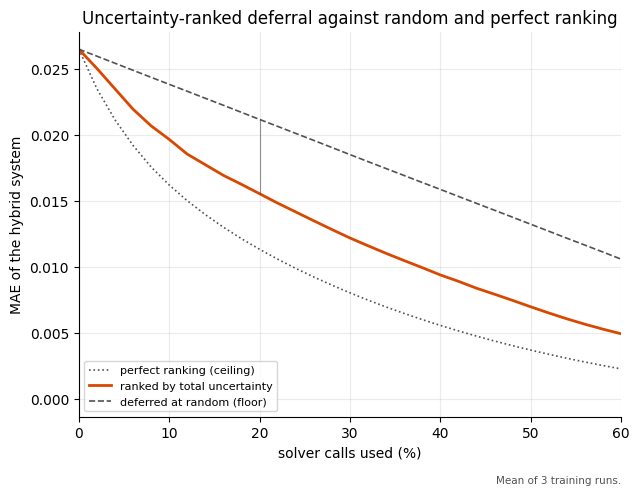

In [48]:
SCORE = 'mae'

RATES = np.linspace(0.0, 1.0, 51)


def absolute_error(y_true, mean, variance):
    del variance  # unused, kept so this matches crps_gaussian's signature
    return np.abs(np.asarray(y_true) - np.asarray(mean))


SCORERS = {
    'crps': (crps_gaussian, 'CRPS', 'Miscalibrated intervals, and the ranking still works'),
    'mae': (
        absolute_error,
        'MAE',
        'Uncertainty-ranked deferral against random and perfect ranking',
    ),
}
score_fn, score_label, score_title = SCORERS[SCORE]


def curves_for(split, seed, region='out'):
    """The five deferral curves for one seed. The oracle ranks by the plotted
    score itself, so it stays a true ceiling no matter which score is active."""
    df = points_for(split, seed)
    df = df[df['region'] == region]
    score = score_fn(df['y_true'], df['mean'], df['total_variance'])
    rng = np.random.default_rng(seed)
    return {
        'oracle': deferral_curve(score, score, RATES),
        'total': deferral_curve(score, df['total_variance'], RATES),
        'aleatoric': deferral_curve(score, df['aleatoric_variance'], RATES),
        'epistemic': deferral_curve(score, df['epistemic_variance'], RATES),
        'random': np.mean(
            [deferral_curve(score, rng.permutation(len(score)), RATES) for _ in range(50)],
            axis=0,
        ),
    }


per_seed = [curves_for('tail', s) for s in SEEDS]

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 5))

# Only total-ranked is drawn; aleatoric and epistemic land within a few
# percent of it and are reported in the markdown instead.
RANKINGS = {
    'oracle': ('perfect ranking (ceiling)', COLOR_NEUTRAL, ':', 1.2),
    'total': ('ranked by total uncertainty', COLOR_TAIL, '-', 2.0),
    'random': ('deferred at random (floor)', COLOR_NEUTRAL, '--', 1.2),
}

x = RATES * 100
means = {}

for name, (label, color, style, width) in RANKINGS.items():
    mean = np.mean([c[name] for c in per_seed], axis=0)
    means[name] = mean
    ax.plot(x, mean, style, color=color, linewidth=width, label=label)

at_20 = {k: float(np.interp(0.2, RATES, v)) for k, v in means.items()}

# Cross-check seed 0 against the committed artifact for whichever score is active.
artifact = load_results('deferral' if SCORE == 'crps' else f'deferral_{SCORE}')['results']
seed0_at_20 = float(np.interp(0.2, RATES, per_seed[0]['total']))
assert abs(seed0_at_20 - artifact['out']['rankings']['total']['score_at']['0.2']) < 1e-12

ax.annotate(
    f'Mean of {len(SEEDS)} training runs.',
    xy=(1.0, 0.0),
    xycoords='axes fraction',
    xytext=(0, -42),
    textcoords='offset points',
    ha='right',
    va='top',
    fontsize=7.5,
    color=COLOR_NEUTRAL,
)

ax.plot([20, 20], [at_20['total'], at_20['random']], color=COLOR_NEUTRAL, lw=0.8, alpha=0.6)

ax.set_xlim(0, 60)
ax.set_xlabel('solver calls used (%)')
ax.set_ylabel(f'{score_label} of the hybrid system')
ax.set_title(score_title)
ax.legend(fontsize=8, loc='lower left')

keep(fig, 'deferral_curve' if SCORE == 'crps' else 'deferral_curve_mae')


## Figure 8: the fallback does not always answer

A caveat Figure 7 needs. That deferral curve credits every deferred shape
with the exact solver answer, which assumes the solver always succeeds. It
doesn't, and it fails most often in exactly the region deferral sends the
most work to.

**The apparent finding.** Failure rate forms a U: 42% at the compact end,
39% at the extended end, only 4% in the middle. Below the tail cutoff it's
31.2% versus 11.6% above, a 2.68x difference.

**The real finding.** That U isn't about geometry. Every failure comes from
one specific generation method, and within that method alone, the compact
region is barely riskier (1.11x). The compact region just happens to contain
far more shapes from that one method. So solver reliability depends on how a
shape was generated, not on its shape.

**This doesn't make Figure 7 wrong.** Every shape in this dataset did solve,
by construction. It matters for deployment: crediting only the roughly 69%
of deferred shapes that would actually solve turns the 41% error cut at 20%
deferral into about 28%. Deferral still beats random by the same margin,
since random deferral hits the same failure rate. Only the absolute level
moves.


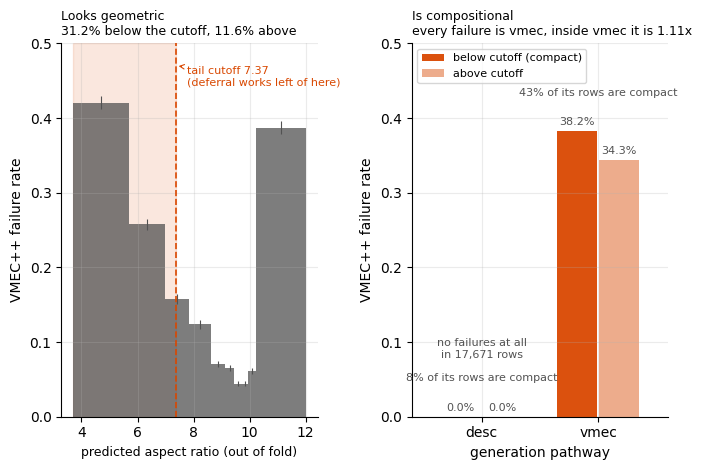

In [49]:
solver = load_results('solver_failures')['results']
bins = pd.DataFrame(solver['bins'])
cutoff = solver['cutoff']

fig, (ax_u, ax_path) = plt.subplots(1, 2, figsize=(FIG_WIDTH, 4.8))

# Left: the U. Bars span their actual bin width, so the wide end bins are not
# drawn as if they were as narrow as the dense middle ones.
ax_u.bar(
    bins['a_lo'],
    bins['rate'],
    width=bins['a_hi'] - bins['a_lo'],
    align='edge',
    color=COLOR_NEUTRAL,
    alpha=0.75,
    yerr=bins['stderr'],
    error_kw={'lw': 0.8, 'ecolor': COLOR_NEUTRAL},
)
ax_u.axvspan(bins['a_lo'].min(), cutoff, color=COLOR_TAIL, alpha=0.13, zorder=0)
ax_u.axvline(cutoff, color=COLOR_TAIL, linestyle='--', linewidth=1.2)
ax_u.annotate(
    f'tail cutoff {cutoff:.2f}\n(deferral works left of here)',
    xy=(cutoff, 0.47),
    xytext=(cutoff + 0.4, 0.47),
    fontsize=8,
    color=COLOR_TAIL,
    va='top',
    ha='left',
    arrowprops={'arrowstyle': '->', 'color': COLOR_TAIL, 'lw': 0.8},
)
ax_u.set_ylim(0, 0.50)
ax_u.set_xlabel('predicted aspect ratio (out of fold)', fontsize=9)
ax_u.set_ylabel('VMEC++ failure rate')
ax_u.set_title(
    f'Looks geometric\n{solver["below_cutoff"]["rate"]:.1%} below the cutoff, '
    f'{solver["above_cutoff"]["rate"]:.1%} above',
    fontsize=9,
    loc='left',
)

# Right: the same comparison inside each generator, which is what dissolves it.
confound = pd.DataFrame(solver['pathway_confound'])
x = np.arange(len(confound))
for offset, key, label, alpha in [
    (-0.18, 'rate_below', 'below cutoff (compact)', 0.95),
    (0.18, 'rate_above', 'above cutoff', 0.45),
]:
    ax_path.bar(x + offset, confound[key], width=0.34, color=COLOR_TAIL, alpha=alpha, label=label)
    for xi, rate in zip(x, confound[key], strict=True):
        ax_path.annotate(
            f'{rate:.1%}',
            (xi + offset, rate + 0.008),
            ha='center',
            fontsize=8,
            color=COLOR_NEUTRAL,
        )

for i, row in confound.iterrows():
    # Zero-height bars are invisible, so desc needs its count said in words or
    # the panel reads as missing data rather than as the finding.
    note = f'{row["share_below_cutoff"]:.0%} of its rows are compact'
    if row['rate_below'] == 0 and row['rate_above'] == 0:
        note = f'no failures at all\nin {row["n"]:,} rows\n\n{note}'
    ax_path.annotate(
        note,
        (i, max(row['rate_below'], row['rate_above']) + 0.045),
        ha='center',
        va='bottom',
        fontsize=8,
        color=COLOR_NEUTRAL,
    )

ax_path.set_xticks(x)
ax_path.set_xticklabels(confound['pathway'])
ax_path.set_xlim(-0.6, len(confound) - 0.4)
ax_path.set_ylim(0, 0.50)
ax_path.set_xlabel('generation pathway')
ax_path.set_ylabel('VMEC++ failure rate')
ax_path.legend(fontsize=8, loc='upper left')
vmec_risk = confound.loc[confound['pathway'] == 'vmec', 'relative_risk'].item()
ax_path.set_title(
    f'Is compositional\nevery failure is vmec, inside vmec it is {vmec_risk:.2f}x',
    fontsize=9,
    loc='left',
)

fig.tight_layout()

keep(fig, 'solver_failures')


## Figure 9: does the decomposition mean what it claims?

Every earlier figure splits uncertainty into two named pieces: **epistemic**
("the model hasn't seen enough like this") and **aleatoric** ("the world is
genuinely noisy here, more data won't help"). None of them test whether that
split is real, they just use it. This figure does.

Each name makes a testable prediction. Epistemic should shrink as the model
trains on more data, since more examples means less ignorance. Aleatoric
should not, since noise in the world doesn't go away with more data.

To test this, the model is trained at five increasing dataset sizes, twice
at each: once on the real targets, once with a known, fixed amount of noise
(σ = 0.020) added to them. The clean run alone can't test the aleatoric
claim, since without injected noise that term is just the model's own
imperfect fit, and fitting error does shrink with data, which would make the
term look broken even if it isn't.

**The finding.** Left panel: epistemic falls steadily with more data, in
both conditions, as it should. Right panel: subtracting the clean run from
the noisy run isolates the injected noise, and the recovered amount
converges to 0.0208, close to the true injected value of 0.020, while the
model's own fitting error keeps shrinking. Two clean pieces of evidence that
the two terms mean what they say.


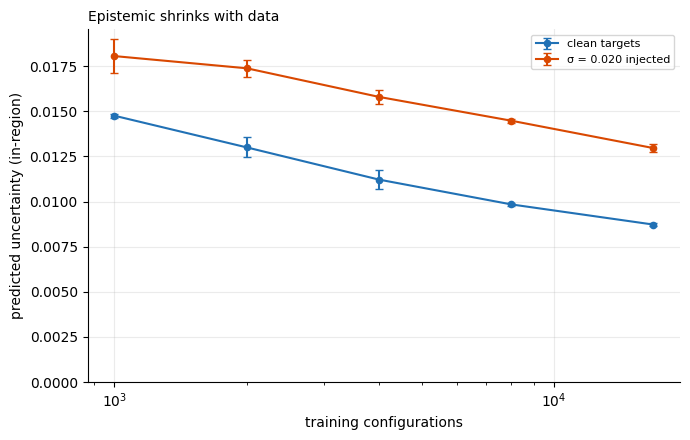

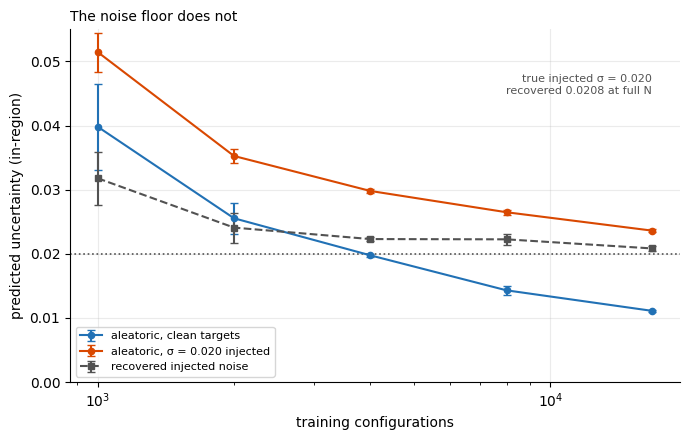

In [50]:
sizes = sorted({c['n_train'] for c in sweep_cells})
CONDITIONS = {0.0: ('clean targets', COLOR_HOLE), 0.02: ('σ = 0.020 injected', COLOR_TAIL)}


def cells_at(sigma, n):
    rows = [c for c in sweep_cells if c['sigma'] == sigma and c['n_train'] == n]
    return sorted(rows, key=lambda c: c['seed'])


def spread(sigma, n, term):
    values = [c['in_region'][term] for c in cells_at(sigma, n)]
    return np.mean(values), np.std(values)


# Figure: epistemic shrinks with data.
fig, ax = plt.subplots()

for sigma, (label, color) in CONDITIONS.items():
    stats = [spread(sigma, n, 'epistemic') for n in sizes]
    ax.errorbar(
        sizes,
        [m for m, _ in stats],
        yerr=[s for _, s in stats],
        fmt='o-',
        color=color,
        markersize=4.5,
        capsize=3,
        label=label,
    )

ax.set_xscale('log')
ax.set_xlabel('training configurations')
ax.set_ylabel('predicted uncertainty (in-region)')
ax.set_ylim(0, None)
ax.set_title('Epistemic shrinks with data', fontsize=10, loc='left')
# Curves fall left to right, so the top-right corner is the emptiest spot.
ax.legend(fontsize=8, loc='upper right')
fig.tight_layout()

keep(fig, 'n_sweep_epistemic')


# Figure: the noise floor does not.
fig, ax = plt.subplots()

for sigma, (label, color) in CONDITIONS.items():
    stats = [spread(sigma, n, 'aleatoric') for n in sizes]
    ax.errorbar(
        sizes,
        [m for m, _ in stats],
        yerr=[s for _, s in stats],
        fmt='o-',
        color=color,
        markersize=4.5,
        capsize=3,
        label=f'aleatoric, {label}',
    )

# Quadrature subtraction within seed: sqrt(noisy^2 - clean^2) recovers what was
# injected. This is the figure's actual claim, the two curves above are its inputs.
recovered = []
for n in sizes:
    pairs = zip(cells_at(0.0, n), cells_at(0.02, n), strict=True)
    per_seed = [
        np.sqrt(max(b['in_region']['aleatoric'] ** 2 - a['in_region']['aleatoric'] ** 2, 0.0))
        for a, b in pairs
    ]
    recovered.append((np.mean(per_seed), np.std(per_seed)))

ax.errorbar(
    sizes,
    [m for m, _ in recovered],
    yerr=[s for _, s in recovered],
    fmt='s--',
    color=COLOR_NEUTRAL,
    markersize=5,
    capsize=3,
    label='recovered injected noise',
)
ax.axhline(0.020, color=COLOR_NEUTRAL, linestyle=':', linewidth=1.2)

# Top-right, large N: the one spot where all three curves have separated and
# there's empty space, instead of small-N where the dotted line, the recovered
# markers and the noisy curve all sit on top of each other.
ax.annotate(
    f'true injected σ = 0.020\nrecovered {recovered[-1][0]:.4f} at full N',
    (sizes[-1], 0.048),
    ha='right',
    va='top',
    fontsize=8,
    color=COLOR_NEUTRAL,
)

ax.set_xscale('log')
ax.set_xlabel('training configurations')
ax.set_ylabel('predicted uncertainty (in-region)')
ax.set_ylim(0, 0.055)
ax.set_title('The noise floor does not', fontsize=10, loc='left')
# None of the three curves comes near y=0, so the bottom-left corner is clear
# and stays clear of the annotation, which sits at the top-right instead.
ax.legend(fontsize=8, loc='lower left')
fig.tight_layout()

keep(fig, 'n_sweep_aleatoric')


## Figure 10: more data does not fix extrapolation

Figure 9 checked whether the two uncertainty terms behave as claimed. This
asks a different question: does training on more data close the gap between
familiar and unfamiliar shapes?

Each point is the ratio of out-of-region error to in-region error, averaged
over three training runs. It climbs from 1.71 to 3.39 as the training set
grows seventeenfold. In-region error drops 67% over that range; out-of-region
error drops only 29%.

**The honest claim is narrow.** The extra data here is still drawn from the
same region the model already trains on, more of a distribution can't
populate the region it excludes. So this shows that scaling up the existing
dataset does not buy extrapolation reliability. The fix is targeted sampling
in the sparse region, or deferral, not just more data.


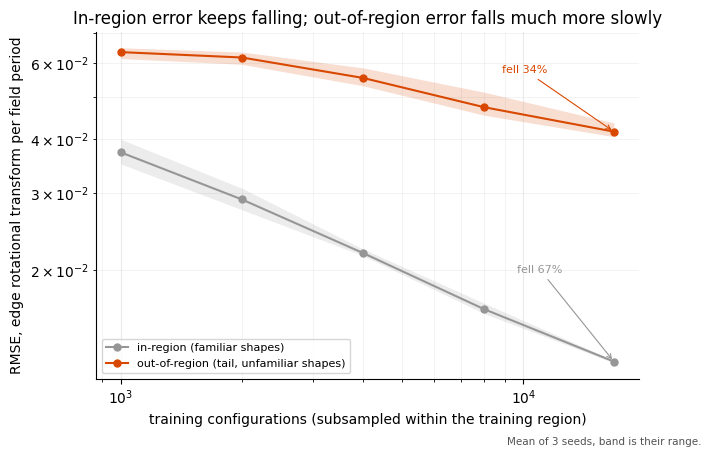

In [51]:
clean = [c for c in sweep_cells if c['sigma'] == 0.0]
clean_sizes = sorted({c['n_train'] for c in clean})
seeds_here = sorted({c['seed'] for c in clean})

# A single out/in ratio line was ambiguous about what was actually moving: a
# falling ratio could mean either curve doing the work. Two RMSE traces show it
# directly.
rmse_in = {(c['n_train'], c['seed']): c['in_region']['rmse'] for c in clean}
rmse_out = {(c['n_train'], c['seed']): c['out_region']['rmse'] for c in clean}

in_curves = [[rmse_in[(n, s)] for n in clean_sizes] for s in seeds_here]
out_curves = [[rmse_out[(n, s)] for n in clean_sizes] for s in seeds_here]

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 4.5))

in_mean = band(ax, clean_sizes, in_curves, COLOR_TRAIN)
ax.plot(clean_sizes, in_mean, 'o-', color=COLOR_TRAIN, markersize=5, label='in-region (familiar shapes)')

out_mean = band(ax, clean_sizes, out_curves, COLOR_TAIL)
ax.plot(
    clean_sizes, out_mean, 'o-', color=COLOR_TAIL, markersize=5,
    label='out-of-region (tail, unfamiliar shapes)',
)

# Computed from the plotted means, not quoted from a prior write-up: an earlier
# draft of this figure's caption used a seed-0-only fall (29%) for the
# out-of-region side while pairing it with the three-seed mean (67%) for the
# in-region side. The three-seed fall for both is 67% and 34%.
in_fall = 1 - in_mean[-1] / in_mean[0]
out_fall = 1 - out_mean[-1] / out_mean[0]

ax.annotate(
    f'fell {in_fall:.0%}',
    xy=(clean_sizes[-1], in_mean[-1]),
    xytext=(clean_sizes[2] * 2.75, 0.02),
    ha='center',
    va='center',
    fontsize=8,
    color=COLOR_TRAIN,
    arrowprops={'arrowstyle': '->', 'color': COLOR_TRAIN, 'lw': 0.8},
)
ax.annotate(
    f'fell {out_fall:.0%}',
    xy=(clean_sizes[-1], out_mean[-1]),
    xytext=(clean_sizes[-1] * 0.6, out_mean[-1] * 1.35),
    ha='center',
    va='bottom',
    fontsize=8,
    color=COLOR_TAIL,
    arrowprops={'arrowstyle': '->', 'color': COLOR_TAIL, 'lw': 0.8},
)


ax.set_xscale('log')
ax.set_yscale('log')
ax.minorticks_on()
ax.grid(which='minor', color=COLOR_NEUTRAL, alpha=0.12, linewidth=0.4)

ax.set_xlabel('training configurations (subsampled within the training region)')
ax.set_ylabel('RMSE, edge rotational transform per field period')
ax.set_title('In-region error keeps falling; out-of-region error falls much more slowly')
ax.legend(fontsize=8, loc='lower left')

fig.text(
    0.99,
    -0.02,
    f'Mean of {len(seeds_here)} seeds, band is their range.',
    ha='right',
    va='top',
    fontsize=7.5,
    color=COLOR_NEUTRAL,
)

keep(fig, 'gap_vs_n')

## Figure 11: the noise floor

**What's plotted.** For each target metric, pick pairs of shapes from the
dataset and measure two things: how far apart they are as inputs (in the 80
boundary coefficients), and how different their computed metric is. The dots
show that relationship, binned by distance. The dashed line extends that
trend back to zero distance, if two shapes were literally identical, how
different would their answers be? That extrapolated value is the "floor."

**Why it matters.** This isn't about the model. It's checking whether the
*data itself* is noisy, whether the same shape solved twice could give two
different answers. If it did, some of what the model later calls "aleatoric
uncertainty" would be genuine, unavoidable noise, not just the model's own
limitation.

**The answer: no.** The floor comes out essentially zero, far below a
conservative threshold set in advance. Near-identical shapes give
near-identical answers, since the physics solver is deterministic. This is
the reason the notebook treats "aleatoric uncertainty" elsewhere as the
model's own misfit rather than real noise in the world, this figure is what
that claim rests on.


noise floor targets: ['edge_rot_transform', 'log10_qi']


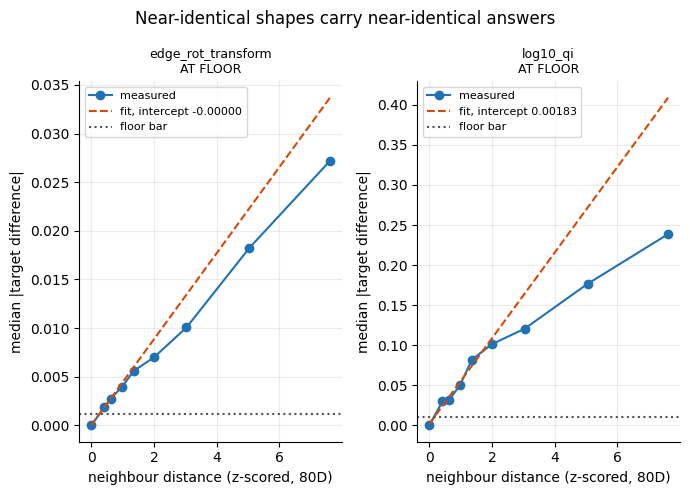

In [52]:
noise = load_results('stage_2_noise_floor')['results']

print('noise floor targets:', list(noise['residual_spread']))

residual_spread = noise['residual_spread']

fig, axes = plt.subplots(1, len(residual_spread), figsize=(FIG_WIDTH, 5))
axes = np.atleast_1d(axes)

for ax, (name, result) in zip(axes, residual_spread.items(), strict=False):
    d = [b['median_distance'] for b in result['bins']]
    gap = [b['median_delta'] for b in result['bins']]

    ax.plot(d, gap, 'o-', color=COLOR_HOLE, label='measured')

    xs = np.linspace(0, max(d), 50)
    ax.plot(
        xs,
        result['intercept'] + result['slope'] * xs,
        '--',
        color=COLOR_TAIL,
        label=f'fit, intercept {result["intercept"]:.5f}',
    )
    ax.axhline(result['bar'], color=COLOR_NEUTRAL, linestyle=':', label='floor bar')

    ax.set_xlabel('neighbour distance (z-scored, 80D)')
    ax.set_ylabel('median |target difference|')
    ax.set_title(f'{name}\n{result["verdict"]}', fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle('Near-identical shapes carry near-identical answers')
# Plain tight_layout() doesn't reserve room for suptitle, so it draws over the
# per-panel titles. rect caps the axes region at 88% of the figure height,
# leaving the top 12% free for the suptitle to sit above everything else.
fig.tight_layout(rect=(0, 0, 1, 1))

keep(fig, 'noise_floor')


## Save

Writes everything stashed in `FIGS` to `figures/` as PNG and PDF. Only the
figures whose cells you have run are present, so re-run a cell before saving if
you changed it.

In [53]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# PDFs embed a creation timestamp, so without this every run rewrites all 13
# of them with identical content and git shows a diff that means nothing. PNGs
# are already deterministic, which is what makes them the regression check: if a
# PNG changes after a refactor, the figure really changed.
PDF_METADATA = {'CreationDate': None}

# savefig.bbox is 'tight', which crops each figure to whatever it actually drew,
# so a figure with short axis labels came out narrower than its neighbours. These
# two zero-alpha anchors sit at the left and right edges of the canvas, which
# pins the horizontal extent to FIG_WIDTH while leaving the vertical crop free to
# expand for the captions that sit below the axes.
for fig in FIGS.values():
    for x in (0.0, 1.0):
        fig.text(x, 0.5, ' ', alpha=0)

for name, fig in FIGS.items():
    fig.savefig(FIGURES_DIR / f'{name}.png')
    fig.savefig(FIGURES_DIR / f'{name}.pdf', metadata=PDF_METADATA)
    print(f'wrote figures/{name}.png and .pdf')


wrote figures/split_design.png and .pdf
wrote figures/distance_error.png and .pdf
wrote figures/coverage_distance.png and .pdf
wrote figures/pit_distance.png and .pdf
wrote figures/coverage_nominal.png and .pdf
wrote figures/pit_histograms.png and .pdf
wrote figures/recalibration_coverage.png and .pdf
wrote figures/deferral_curve_mae.png and .pdf
wrote figures/solver_failures.png and .pdf
wrote figures/n_sweep_epistemic.png and .pdf
wrote figures/n_sweep_aleatoric.png and .pdf
wrote figures/gap_vs_n.png and .pdf
wrote figures/noise_floor.png and .pdf
